# Multi-Omics PANCAN Data Pipeline
### mRNA · CNV · Mutation · Methylation (450K) → ID-to-Gene Mapping → Aligned Matrices

**Fixes applied:**
- ✅ BUG 1 & 2: Added missing Phenotype loading cell (`pheno`, `valid_patients_pheno` now defined)  
- ✅ BUG 3: Auto-detect probe map ID column (`id` vs `#id`) instead of hardcoded `usecols`  
- ✅ BUG 4: NPZ on-disk chunking for 13 GB methylation file — running accumulator prevents RAM explosion  
- ✅ BUG 5: `.str.strip()` on gene names after comma-split/explode  
- ✅ BUG 6: `.round(0).astype(np.int8)` for mutation matrix  
- ✅ BUG 7: Dynamic CNV bar colors keyed by actual unique values  
- ✅ BUG 8: Multi-omics alignment moved to its own cell  
- ✅ BUG 9: `METH_LOADED` initialised at top of setup cell as safe default  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import os
import glob
import shutil
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']  = 120
plt.rcParams['font.size']   = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid')

def section(title):
    print('\n' + '═'*65)
    print(f'  {title}')
    print('═'*65)

def mem_usage(df, name):
    mb = df.memory_usage(deep=True).sum() / 1e6
    print(f'  [{name}] RAM usage: {mb:.1f} MB | shape: {df.shape}')

# ═══════════════════════════════════════════════════════════════
#  FILE PATHS  — update to your Kaggle input paths
# ═══════════════════════════════════════════════════════════════
BASE = '/kaggle/input/datasets/proutkarshtiwari/multi-omnics-data'

path_mrna     = f'{BASE}/EBAdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena'
path_cnv      = f'{BASE}/Gistic2_CopyNumber_Gistic2_all_thresholded.by_genes'
path_mut      = f'{BASE}/mc3.v0.2.8.PUBLIC.nonsilentGene.xena'
path_pheno    = f'{BASE}/TCGA_phenotype_denseDataOnlyDownload.tsv'

path_meth     = (f'{BASE}/jhu-usc.edu_PANCAN_HumanMethylation450.betaValue_whitelisted'
                 f'.tsv.synapse_download_5096262.xena/'
                 f'jhu-usc.edu_PANCAN_HumanMethylation450.betaValue_whitelisted'
                 f'.tsv.synapse_download_5096262.xena')
path_meth_map = f'{BASE}/probeMap_illuminaMethyl450_hg19_GPL16304_TCGAlegacy'

# ── CONFIG ──────────────────────────────────────────────────────
INCLUDE_METHYLATION = True       # set False to skip methylation entirely
METH_CHUNK_SIZE     = 10_000     # probes per chunk   (tune ↓ if RAM is tight)
PROBE_NAN_THRESH    = 0.30       # drop probe if >30 % samples are NaN
SAMPLE_NAN_THRESH   = 0.50       # drop sample if >50 % probes are NaN  (alignment step)
MRNA_VAR_QUANTILE   = 0.10       # remove bottom 10 % lowest-variance genes
MIN_CLASS_SAMPLES   = 10         # for EDA visualisation threshold line

# ── BUG 9 FIX: safe default — overwritten in the methylation cell ──
METH_LOADED = False

# Temp folder for per-chunk NPZ files (auto-cleaned after use)
NPZ_CHUNK_DIR = '/kaggle/working/meth_npz_chunks'

print('Setup complete.')
print(f'INCLUDE_METHYLATION = {INCLUDE_METHYLATION}')
print(f'Methylation chunk size = {METH_CHUNK_SIZE:,} probes')
print(f'NPZ temp dir = {NPZ_CHUNK_DIR}')


Setup complete.
INCLUDE_METHYLATION = True
Methylation chunk size = 10,000 probes
NPZ temp dir = /kaggle/working/meth_npz_chunks


## Cell 2 — Phenotype (labels) · BUG 1 & 2 FIX
*This cell was completely missing — `pheno` and `valid_patients_pheno` caused NameErrors throughout the original notebook.*

In [2]:
section('2. PHENOTYPE — LOAD & CLEAN')

print('Loading phenotype file...')
pheno = pd.read_csv(path_pheno, sep='\t', index_col=0)

# ── Standardise patient IDs to 15-character TCGA barcode ──
pheno.index = pheno.index.str[:15]
pheno = pheno[~pheno.index.duplicated(keep='first')]

# ── Inspect available columns ──
print(f'Phenotype shape: {pheno.shape}')
print('Columns:', pheno.columns.tolist()[:10], '...')

# ── Identify the primary disease / cancer type column ──
# Common column names across TCGA Xena releases
_DISEASE_CANDIDATES = ['_primary_disease', 'primary_disease',
                       '_study', 'study', '_cohort', 'cohort',
                       'cancer type abbreviation', '_cancer_type']
disease_col = None
for c in _DISEASE_CANDIDATES:
    if c in pheno.columns:
        disease_col = c
        break

if disease_col is None:
    # Fall back to first string column that looks like cancer labels
    for c in pheno.columns:
        if pheno[c].dtype == object and pheno[c].nunique() < 100:
            disease_col = c
            break

if disease_col is None:
    raise ValueError(
        'Could not auto-detect cancer-type column in phenotype file. '
        'Set disease_col manually from: ' + str(pheno.columns.tolist())
    )

# Rename to a single consistent key used everywhere downstream
if disease_col != '_primary_disease':
    pheno = pheno.rename(columns={disease_col: '_primary_disease'})

# ── Drop samples with no label ──
before = len(pheno)
pheno = pheno.dropna(subset=['_primary_disease'])
pheno['_primary_disease'] = pheno['_primary_disease'].str.strip().str.lower()
print(f'Dropped {before - len(pheno):,} samples with missing cancer label')

# ── Summary ──
print(f'\nFinal phenotype: {pheno.shape[0]:,} samples, '
      f'{pheno["_primary_disease"].nunique()} cancer types')
print(pheno['_primary_disease'].value_counts().head(10).to_string())

# Track valid patients for alignment step
valid_patients_pheno = set(pheno.index)
print(f'\nvalid_patients_pheno: {len(valid_patients_pheno):,}')



═════════════════════════════════════════════════════════════════
  2. PHENOTYPE — LOAD & CLEAN
═════════════════════════════════════════════════════════════════
Loading phenotype file...
Phenotype shape: (12804, 3)
Columns: ['sample_type_id', 'sample_type', '_primary_disease'] ...
Dropped 0 samples with missing cancer label

Final phenotype: 12,804 samples, 33 cancer types
_primary_disease
breast invasive carcinoma                1241
kidney clear cell carcinoma               944
lung adenocarcinoma                       705
ovarian serous cystadenocarcinoma         627
lung squamous cell carcinoma              626
glioblastoma multiforme                   614
head & neck squamous cell carcinoma       604
uterine corpus endometrioid carcinoma     595
stomach adenocarcinoma                    581
thyroid carcinoma                         580

valid_patients_pheno: 12,804


## Cell 3 — mRNA EDA & Cleaning


═════════════════════════════════════════════════════════════════
  3. mRNA EDA & CLEANING
═════════════════════════════════════════════════════════════════
Loading mRNA (transposing — genes as rows in raw file)...
Cleaned mRNA shape: (11060, 20530)
  [mRNA] RAM usage: 909.0 MB | shape: (11060, 20530)

mRNA missing values:
  Genes with any NaN:   4196 / 20530
  Samples with any NaN: 1750 / 11060
  Max NaN% per gene:    15.82%


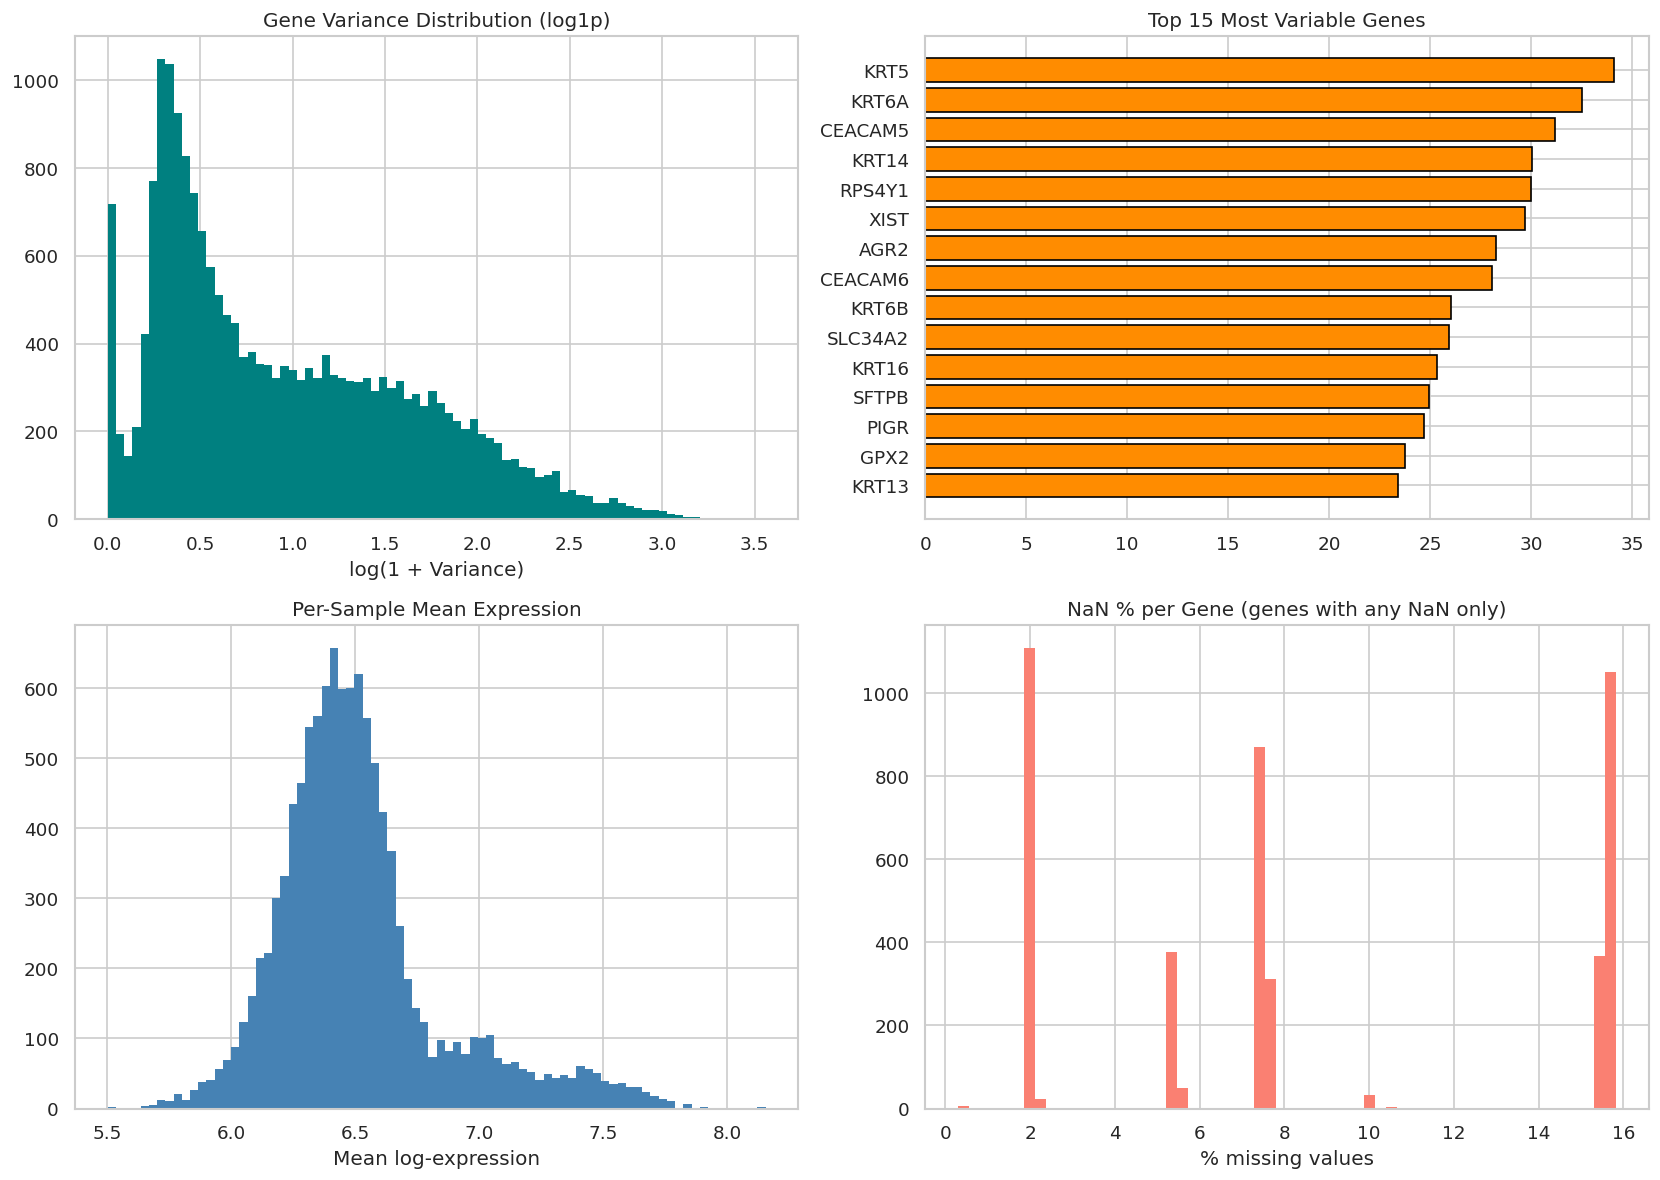


valid_patients_mrna: 11,060


In [3]:
section('3. mRNA EDA & CLEANING')

print('Loading mRNA (transposing — genes as rows in raw file)...')
mrna = pd.read_csv(path_mrna, sep='\t', index_col=0).T

# ── Clean patient IDs ──
mrna.index = mrna.index.str[:15]
mrna = mrna[~mrna.index.duplicated(keep='first')]

# ── Clean Gene symbols  (TCGA format: 'GeneSymbol|GeneID') ──
mrna.columns = [str(c).split('|')[0] for c in mrna.columns]
mrna = mrna.loc[:, ~mrna.columns.duplicated(keep='first')]

# ── Downcast to float32 (saves ~50 % RAM vs float64) ──
mrna = mrna.astype(np.float32)
print(f'Cleaned mRNA shape: {mrna.shape}')
mem_usage(mrna, 'mRNA')

# ── EDA stats ──
gene_var       = mrna.var(axis=0)
sample_mean    = mrna.mean(axis=1)
nan_per_gene   = mrna.isnull().mean(axis=0)
nan_per_sample = mrna.isnull().mean(axis=1)

print(f'\nmRNA missing values:')
print(f'  Genes with any NaN:   {(nan_per_gene > 0).sum()} / {mrna.shape[1]}')
print(f'  Samples with any NaN: {(nan_per_sample > 0).sum()} / {mrna.shape[0]}')
print(f'  Max NaN% per gene:    {nan_per_gene.max()*100:.2f}%')

# ── EDA Plots ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(np.log1p(gene_var), bins=80, color='teal', edgecolor='none')
axes[0, 0].set_title('Gene Variance Distribution (log1p)')
axes[0, 0].set_xlabel('log(1 + Variance)')

top15 = gene_var.nlargest(15)
axes[0, 1].barh(top15.index, top15.values, color='darkorange', edgecolor='black')
axes[0, 1].set_title('Top 15 Most Variable Genes')
axes[0, 1].invert_yaxis()

axes[1, 0].hist(sample_mean, bins=80, color='steelblue', edgecolor='none')
axes[1, 0].set_title('Per-Sample Mean Expression')
axes[1, 0].set_xlabel('Mean log-expression')

nan_nonzero = nan_per_gene[nan_per_gene > 0] * 100
if len(nan_nonzero):
    axes[1, 1].hist(nan_nonzero, bins=60, color='salmon', edgecolor='none')
axes[1, 1].set_title('NaN % per Gene (genes with any NaN only)')
axes[1, 1].set_xlabel('% missing values')

plt.tight_layout(); plt.show()

valid_patients_mrna = set(mrna.index)
valid_genes_mrna    = set(mrna.columns)

del gene_var, sample_mean, nan_per_gene, nan_per_sample
gc.collect()
print(f'\nvalid_patients_mrna: {len(valid_patients_mrna):,}')


## Cell 4 — CNV EDA & Cleaning · BUG 7 FIX
*Dynamic bar colours keyed by actual unique values — no crash when not all 5 copy-number states are present.*


═════════════════════════════════════════════════════════════════
  4. CNV EDA & CLEANING
═════════════════════════════════════════════════════════════════
Loading CNV...
Cleaned CNV shape: (10845, 23705)
CNV missing values: 0 → filling with 0 (diploid normal)
  [CNV] RAM usage: 258.0 MB | shape: (10845, 23705)


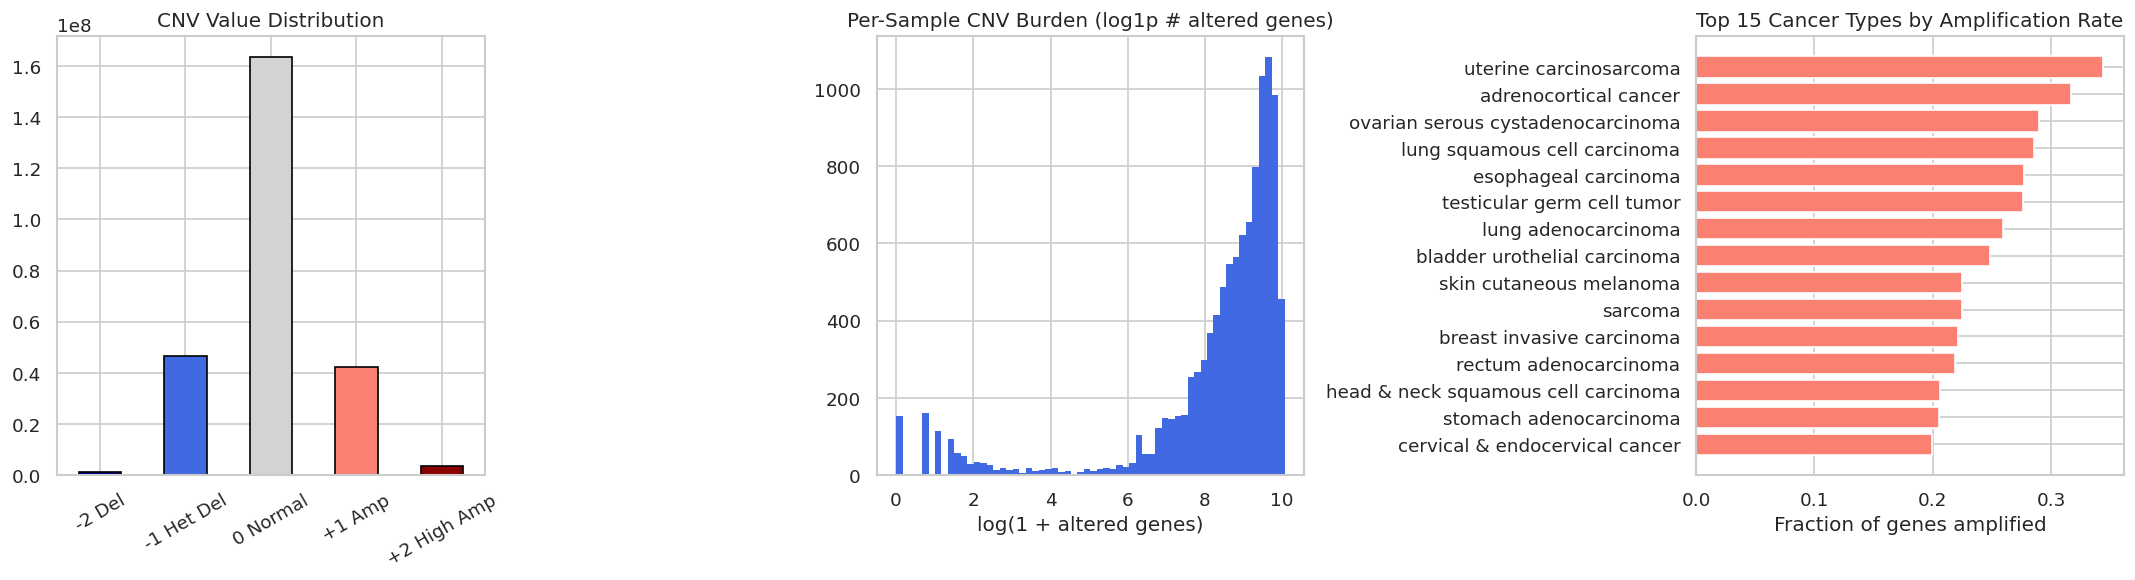


valid_patients_cnv: 10,845


In [4]:
section('4. CNV EDA & CLEANING')

print('Loading CNV...')
cnv = pd.read_csv(path_cnv, sep='\t', index_col=0).T

# ── Clean patient IDs ──
cnv.index = cnv.index.str[:15]
cnv = cnv[~cnv.index.duplicated(keep='first')]

# ── Clean Gene symbols ──
cnv.columns = [str(c).split('|')[0] for c in cnv.columns]
cnv = cnv.loc[:, ~cnv.columns.duplicated(keep='first')]
print(f'Cleaned CNV shape: {cnv.shape}')

# ── Missing Value Handling ──
# CNV uses discrete −2/−1/0/+1/+2; missing → normal diploid (0)
nan_count = cnv.isnull().sum().sum()
print(f'CNV missing values: {nan_count:,} → filling with 0 (diploid normal)')
cnv = cnv.fillna(0).astype(np.int8)      # int8 saves ~87 % vs float64
mem_usage(cnv, 'CNV')

# ── EDA Plots ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# BUG 7 FIX: build colours dynamically from the values actually present
val_counts = cnv.stack().value_counts().sort_index()
_CNV_COLOUR_MAP = {-2: 'navy', -1: 'royalblue', 0: 'lightgray',
                   1: 'salmon', 2: 'darkred'}
bar_colors = [_CNV_COLOUR_MAP.get(int(v), 'gray') for v in val_counts.index]
val_counts.plot(kind='bar', color=bar_colors, edgecolor='black', ax=axes[0])
axes[0].set_title('CNV Value Distribution')
_label_map = {-2: '-2 Del', -1: '-1 Het Del', 0: '0 Normal',
               1: '+1 Amp',  2: '+2 High Amp'}
axes[0].set_xticklabels([_label_map.get(int(v), str(v))
                         for v in val_counts.index], rotation=30)

sample_burden = (cnv != 0).sum(axis=1)
axes[1].hist(np.log1p(sample_burden), bins=60, color='royalblue', edgecolor='none')
axes[1].set_title('Per-Sample CNV Burden (log1p # altered genes)')
axes[1].set_xlabel('log(1 + altered genes)')

# Amplification rate per cancer type (pheno is now loaded — Bug 1 fixed)
cnv_labeled = cnv.copy()
cnv_labeled.index = cnv_labeled.index.map(
    lambda x: pheno.loc[x, '_primary_disease'] if x in pheno.index else 'Unknown'
)
amp_rate = (cnv_labeled > 0).mean(axis=1).groupby(level=0).mean()
amp_rate = amp_rate.sort_values(ascending=False).head(15)
axes[2].barh(amp_rate.index, amp_rate.values, color='salmon')
axes[2].set_title('Top 15 Cancer Types by Amplification Rate')
axes[2].invert_yaxis()
axes[2].set_xlabel('Fraction of genes amplified')

plt.tight_layout(); plt.show()

valid_patients_cnv = set(cnv.index)
valid_genes_cnv    = set(cnv.columns)

del cnv_labeled, val_counts, sample_burden, amp_rate
gc.collect()
print(f'\nvalid_patients_cnv: {len(valid_patients_cnv):,}')


## Cell 5 — Mutation EDA & Cleaning · BUG 6 FIX
*`.round(0).astype(np.int8)` prevents silent truncation of fractional values.*


═════════════════════════════════════════════════════════════════
  5. MUTATION EDA & CLEANING
═════════════════════════════════════════════════════════════════
Loading Mutation...
Cleaned Mutation shape: (9104, 40543)
Mutation missing values: 0 → filling with 0 (wildtype)
Sparsity (fraction zeros): 99.6%
  [Mutation] RAM usage: 370.0 MB | shape: (9104, 40543)


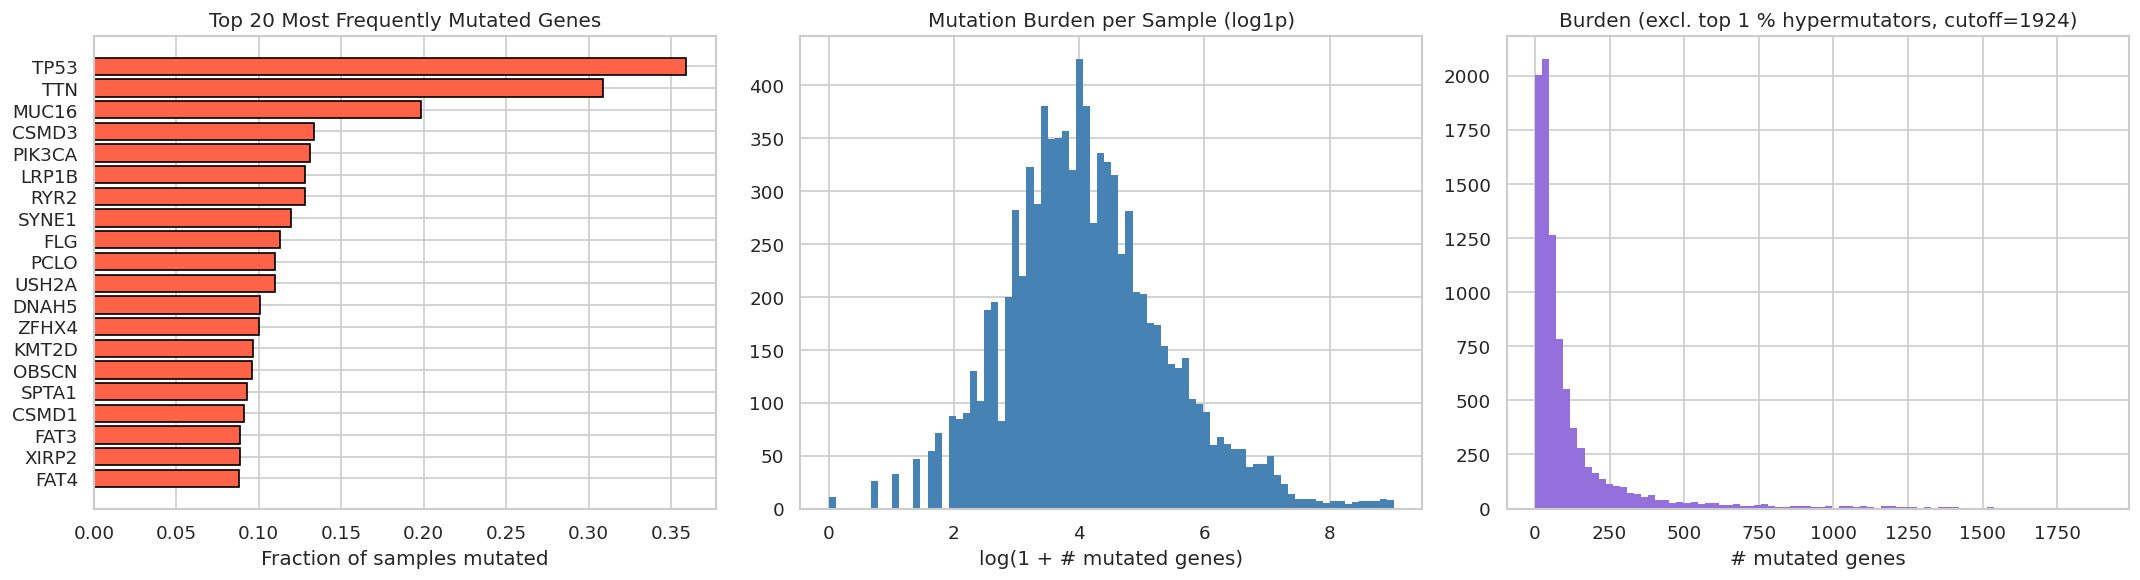


valid_patients_mut: 9,104


In [5]:
section('5. MUTATION EDA & CLEANING')

print('Loading Mutation...')
mut = pd.read_csv(path_mut, sep='\t', index_col=0).T

mut.index = mut.index.str[:15]
mut = mut[~mut.index.duplicated(keep='first')]

mut.columns = [str(c).split('|')[0] for c in mut.columns]
mut = mut.loc[:, ~mut.columns.duplicated(keep='first')]
print(f'Cleaned Mutation shape: {mut.shape}')

# ── Missing Value Handling ──
nan_count = mut.isnull().sum().sum()
tmp       = mut.fillna(0)
sparsity  = (tmp == 0).mean().mean()
print(f'Mutation missing values: {nan_count:,} → filling with 0 (wildtype)')
print(f'Sparsity (fraction zeros): {sparsity*100:.1f}%')

# BUG 6 FIX: round before int8 cast to avoid silent truncation
mut = tmp.round(0).astype(np.int8)
del tmp
mem_usage(mut, 'Mutation')

# ── EDA Plots ──
mut_rate      = mut.mean(axis=0)
sample_burden = mut.sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

top20 = mut_rate.nlargest(20)
axes[0].barh(top20.index, top20.values, color='tomato', edgecolor='black')
axes[0].set_title('Top 20 Most Frequently Mutated Genes')
axes[0].set_xlabel('Fraction of samples mutated')
axes[0].invert_yaxis()

axes[1].hist(np.log1p(sample_burden), bins=80, color='steelblue', edgecolor='none')
axes[1].set_title('Mutation Burden per Sample (log1p)')
axes[1].set_xlabel('log(1 + # mutated genes)')

q99 = sample_burden.quantile(0.99)
axes[2].hist(sample_burden[sample_burden <= q99], bins=80,
             color='mediumpurple', edgecolor='none')
axes[2].set_title(f'Burden (excl. top 1 % hypermutators, cutoff={q99:.0f})')
axes[2].set_xlabel('# mutated genes')

plt.tight_layout(); plt.show()

valid_patients_mut = set(mut.index)
valid_genes_mut    = set(mut.columns)
gc.collect()
print(f'\nvalid_patients_mut: {len(valid_patients_mut):,}')


## Cell 6 — Methylation: Probe Map + NPZ-Chunked Processing

### BUG 3, 4, 5 FIX
| Bug | Fix |
|-----|-----|
| **BUG 3** | Auto-detect ID column name (`id` vs `#id`) from actual file header |
| **BUG 4** | Each chunk → saved as `.npz` on disk immediately, RAM freed. Final combine uses a running-sum accumulator — never holds all chunks in memory at once |
| **BUG 5** | `.str.strip()` on gene names after comma-split/explode |

**How NPZ chunking works:**
1. Read 10 000 probes at a time from the 13 GB file  
2. Filter bad probes → impute → merge probe map → gene-level mean  
3. Save result (genes × samples) as compressed `.npz` on disk, delete from RAM  
4. After all chunks: load each `.npz` one-by-one, accumulate `gene_sum` & `gene_count` dicts  
5. Divide → final `meth` DataFrame — peak RAM ≈ one chunk at a time  


In [6]:
section('6. METHYLATION PROBE MAPPING & NPZ-CHUNKED PROCESSING')

if not INCLUDE_METHYLATION:
    valid_patients_meth = set()
    METH_LOADED = False
    print('Methylation skipped (INCLUDE_METHYLATION=False).')

else:
    # ────────────────────────────────────────────────────────────
    #  STEP 1 — Load & prepare the Probe-to-Gene map
    # ────────────────────────────────────────────────────────────
    print('Loading Probe-to-Gene map...')
    
    # BUG 3 FIX: auto-detect the ID column name.
    # Xena probe maps ship with "#id" (hash prefix) as the first column.
    _probe_map_raw = pd.read_csv(path_meth_map, sep='\t', nrows=0)  # header only
    _all_cols = _probe_map_raw.columns.tolist()
    print(f'  Probe map columns detected: {_all_cols[:6]}')
    
    _id_col   = '#id' if '#id' in _all_cols else 'id'
    _gene_col = 'gene' if 'gene' in _all_cols else _all_cols[1]   # fallback to 2nd col
    
    probe_map = pd.read_csv(path_meth_map, sep='\t',
                            usecols=[_id_col, _gene_col],
                            dtype=str)
    probe_map = probe_map.rename(columns={_id_col: 'id', _gene_col: 'gene'})
    
    # Drop intergenic / unmapped probes
    probe_map = probe_map[~probe_map['gene'].isin(['.', '', 'nan', 'NaN'])]
    
    # BUG 5 FIX: strip whitespace BEFORE exploding (comma-split genes like "A, B")
    probe_map['gene'] = (probe_map['gene']
                         .astype(str)
                         .str.strip()
                         .str.split(','))
    probe_map = probe_map.explode('gene')
    probe_map['gene'] = probe_map['gene'].str.strip()          # strip each part
    probe_map = probe_map[probe_map['gene'] != '']             # remove empty strings
    
    # Build a fast probe_id → [gene, gene, …] lookup dict
    probe_to_genes = probe_map.groupby('id')['gene'].apply(list).to_dict()
    del probe_map; gc.collect()
    print(f'  Probes with gene mapping: {len(probe_to_genes):,}')
    
    # ────────────────────────────────────────────────────────────
    #  STEP 2 — Process 13 GB methylation file in NPZ chunks
    #  BUG 4 FIX: save each chunk to disk immediately; never accumulate in RAM
    # ────────────────────────────────────────────────────────────
    os.makedirs(NPZ_CHUNK_DIR, exist_ok=True)
    # Clean any stale files from a previous interrupted run
    for _f in glob.glob(f'{NPZ_CHUNK_DIR}/meth_chunk_*.npz'):
        os.remove(_f)
    
    print(f'\nProcessing methylation in chunks of {METH_CHUNK_SIZE:,} probes...')
    reader = pd.read_csv(path_meth, sep='\t', index_col=0, chunksize=METH_CHUNK_SIZE)
    
    sample_cols      = None    # captured from first chunk
    total_probes     = 0
    saved_chunks     = 0
    
    for chunk_num, chunk in enumerate(reader):
        total_probes += len(chunk)
        
        # Capture sample column order from first valid chunk
        if sample_cols is None:
            sample_cols = chunk.columns.tolist()
        
        # ── Filter probes: drop those with too many missing values ──
        probe_nan_frac = chunk.isna().mean(axis=1)
        chunk = chunk.loc[probe_nan_frac <= PROBE_NAN_THRESH]
        if len(chunk) == 0:
            continue
        
        # ── Keep only mapped probes early (saves imputation work) ──
        mapped_ids = set(chunk.index) & set(probe_to_genes.keys())
        chunk = chunk.loc[list(mapped_ids)]
        if len(chunk) == 0:
            continue
        
        # ── Median imputation per probe (row-wise) ──
        if chunk.isna().any().any():
            row_medians = chunk.median(axis=1)
            chunk = chunk.T.fillna(row_medians).T   # aligns by probe_id
        
        # ── Convert to float32 early to save RAM ──
        chunk = chunk.astype(np.float32)
        
        # ── Probe ID → Gene Symbol mapping via explode ──
        # Build a long-form records list: one row per (probe, gene)
        records = []
        for probe_id, row_vals in chunk.iterrows():
            for gene in probe_to_genes.get(probe_id, []):
                records.append((gene, row_vals.values))
        
        if not records:
            continue
        
        # Group by gene → mean across all probes mapping to that gene
        gene_labels  = [r[0] for r in records]
        gene_matrix  = np.vstack([r[1] for r in records])   # shape: (n_records, n_samples)
        
        gene_df = pd.DataFrame(gene_matrix,
                               index=gene_labels,
                               columns=chunk.columns,
                               dtype=np.float32)
        gene_df = gene_df.groupby(level=0).mean()   # shape: (n_genes, n_samples)
        
        # ── BUG 4 FIX: save to disk as NPZ, immediately free RAM ──
        npz_path = f'{NPZ_CHUNK_DIR}/meth_chunk_{saved_chunks:05d}.npz'
        np.savez_compressed(
            npz_path,
            data   = gene_df.values.astype(np.float32),
            genes  = np.array(gene_df.index.tolist(),   dtype='U64'),
            samples= np.array(gene_df.columns.tolist(), dtype='U64'),
        )
        del gene_df, records, gene_labels, gene_matrix, chunk
        gc.collect()
        saved_chunks += 1
        
        if (chunk_num + 1) % 5 == 0:
            print(f'  Chunk {chunk_num+1:3d} | {total_probes:,} raw probes scanned | '
                  f'{saved_chunks} NPZ files saved')
    
    print(f'\nAll chunks processed. Total raw probes scanned: {total_probes:,}')
    print(f'NPZ files saved to disk: {saved_chunks}')
    
    # ────────────────────────────────────────────────────────────
    #  STEP 3 — Combine NPZ chunks with running-sum accumulator
    #  Peak RAM = one chunk at a time (not all at once)
    # ────────────────────────────────────────────────────────────
    print('\nCombining NPZ chunks (running accumulator — low RAM)...')
    npz_files = sorted(glob.glob(f'{NPZ_CHUNK_DIR}/meth_chunk_*.npz'))
    
    gene_sum   = {}   # gene_name -> np.ndarray (shape: n_samples)
    gene_count = {}   # gene_name -> int  (how many chunks contributed)
    final_sample_cols = None
    
    for npz_path in npz_files:
        d = np.load(npz_path, allow_pickle=False)
        genes   = d['genes'].astype(str)
        samples = d['samples'].astype(str)
        data    = d['data']                   # shape: (n_genes, n_samples)
        d.close()
        
        if final_sample_cols is None:
            final_sample_cols = samples.tolist()
        
        for i, gene in enumerate(genes):
            if gene in gene_sum:
                gene_sum[gene]   += data[i]
                gene_count[gene] += 1
            else:
                gene_sum[gene]   = data[i].copy()
                gene_count[gene] = 1
        
        del d, genes, samples, data
        gc.collect()
    
    # Build final DataFrame: rows=genes, cols=samples
    all_genes = sorted(gene_sum.keys())
    meth_matrix = np.vstack(
        [gene_sum[g] / gene_count[g] for g in all_genes]
    ).astype(np.float32)
    
    meth = pd.DataFrame(
        meth_matrix.T,                         # transpose → patients × genes
        index   = final_sample_cols,
        columns = all_genes,
    )
    del meth_matrix, gene_sum, gene_count; gc.collect()
    
    # ── Clean patient IDs ──
    meth.index = pd.Index(meth.index).str[:15]
    meth = meth[~meth.index.duplicated(keep='first')]
    
    print(f'Final Mapped Methylation shape: {meth.shape}')
    mem_usage(meth, 'Methylation (Mapped)')
    
    valid_patients_meth = set(meth.index)
    METH_LOADED = True
    
    # ── Clean up temp NPZ files ──
    shutil.rmtree(NPZ_CHUNK_DIR, ignore_errors=True)
    print(f'Cleaned up temp NPZ dir: {NPZ_CHUNK_DIR}')
    
    print(f'\nvalid_patients_meth: {len(valid_patients_meth):,}')



═════════════════════════════════════════════════════════════════
  6. METHYLATION PROBE MAPPING & NPZ-CHUNKED PROCESSING
═════════════════════════════════════════════════════════════════
Loading Probe-to-Gene map...
  Probe map columns detected: ['#id', 'gene', 'chrom', 'chromStart', 'chromEnd', 'strand']
  Probes with gene mapping: 344,298

Processing methylation in chunks of 10,000 probes...
  Chunk   5 | 50,000 raw probes scanned | 5 NPZ files saved
  Chunk  10 | 100,000 raw probes scanned | 10 NPZ files saved
  Chunk  15 | 150,000 raw probes scanned | 15 NPZ files saved
  Chunk  20 | 200,000 raw probes scanned | 20 NPZ files saved
  Chunk  25 | 250,000 raw probes scanned | 25 NPZ files saved
  Chunk  30 | 300,000 raw probes scanned | 30 NPZ files saved
  Chunk  35 | 350,000 raw probes scanned | 35 NPZ files saved
  Chunk  40 | 396,065 raw probes scanned | 40 NPZ files saved

All chunks processed. Total raw probes scanned: 396,065
NPZ files saved to disk: 40

Combining NPZ chunks 

## Cell 7 — Multi-Omics Alignment · BUG 8 FIX
*Alignment moved to its own cell so methylation cell can be re-run independently.*

In [7]:
section('7. MULTI-OMICS ALIGNMENT (Patient & Gene Intersection)')

# ── Patient intersection ──
patient_sets = {
    'Pheno': valid_patients_pheno,    # BUG 2 FIX: now defined in Cell 2
    'mRNA' : valid_patients_mrna,
    'CNV'  : valid_patients_cnv,
    'Mut'  : valid_patients_mut,
}
if METH_LOADED:
    patient_sets['Meth'] = valid_patients_meth

print('Patients per modality:')
for name, ps in patient_sets.items():
    print(f'  {name:6s}: {len(ps):,}')

common_patients = sorted(set.intersection(*patient_sets.values()))
print(f'\nCommon patients (ALL modalities): {len(common_patients):,}')

# ── Gene intersection ──
gene_sets = {
    'mRNA': set(mrna.columns),
    'CNV' : set(cnv.columns),
    'Mut' : set(mut.columns),
}
if METH_LOADED:
    gene_sets['Meth'] = set(meth.columns)

print('\nGenes per modality:')
for name, gs in gene_sets.items():
    print(f'  {name:6s}: {len(gs):,}')

common_genes = sorted(set.intersection(*gene_sets.values()))
print(f'\nCommon genes (ALL modalities): {len(common_genes):,}')

# ── Slice all modalities to the common intersection ──
mrna   = mrna.loc[common_patients, common_genes]
cnv    = cnv.loc[common_patients, common_genes]
mut    = mut.loc[common_patients, common_genes]
labels = pheno.loc[common_patients, ['_primary_disease']]

if METH_LOADED:
    meth = meth.loc[common_patients, common_genes]

print('\nPost-alignment shapes:')
mem_usage(mrna,   'mRNA aligned')
mem_usage(cnv,    'CNV aligned')
mem_usage(mut,    'Mut aligned')
if METH_LOADED:
    mem_usage(meth, 'Meth aligned')
print(f'  [labels] shape: {labels.shape}')

print('\nAll modalities perfectly aligned — ready for modelling. ✅')



═════════════════════════════════════════════════════════════════
  7. MULTI-OMICS ALIGNMENT (Patient & Gene Intersection)
═════════════════════════════════════════════════════════════════
Patients per modality:
  Pheno : 12,804
  mRNA  : 11,060
  CNV   : 10,845
  Mut   : 9,104
  Meth  : 9,639

Common patients (ALL modalities): 7,912

Genes per modality:
  mRNA  : 20,530
  CNV   : 23,705
  Mut   : 40,543
  Meth  : 33,968

Common genes (ALL modalities): 17,574

Post-alignment shapes:
  [mRNA aligned] RAM usage: 556.7 MB | shape: (7912, 17574)
  [CNV aligned] RAM usage: 139.6 MB | shape: (7912, 17574)
  [Mut aligned] RAM usage: 139.6 MB | shape: (7912, 17574)
  [Meth aligned] RAM usage: 556.7 MB | shape: (7912, 17574)
  [labels] shape: (7912, 1)

All modalities perfectly aligned — ready for modelling. ✅


## Cell 8 — Final Filtering & Combined EDA


═════════════════════════════════════════════════════════════════
  8. FINAL FILTERING & COMBINED EDA
═════════════════════════════════════════════════════════════════
Imputing 1,082,242 remaining mRNA NaN values with gene-wise mean...
Removing bottom 10% lowest-variance genes...
Genes after variance filter + meth intersect: 15,816

─── FINAL DATASET SHAPES & MEMORY ───
  [mRNA final] RAM usage: 501.1 MB | shape: (7912, 15816)
  [CNV final] RAM usage: 125.6 MB | shape: (7912, 15816)
  [Mutation final] RAM usage: 125.6 MB | shape: (7912, 15816)
  [Methylation final] RAM usage: 501.1 MB | shape: (7912, 15816)


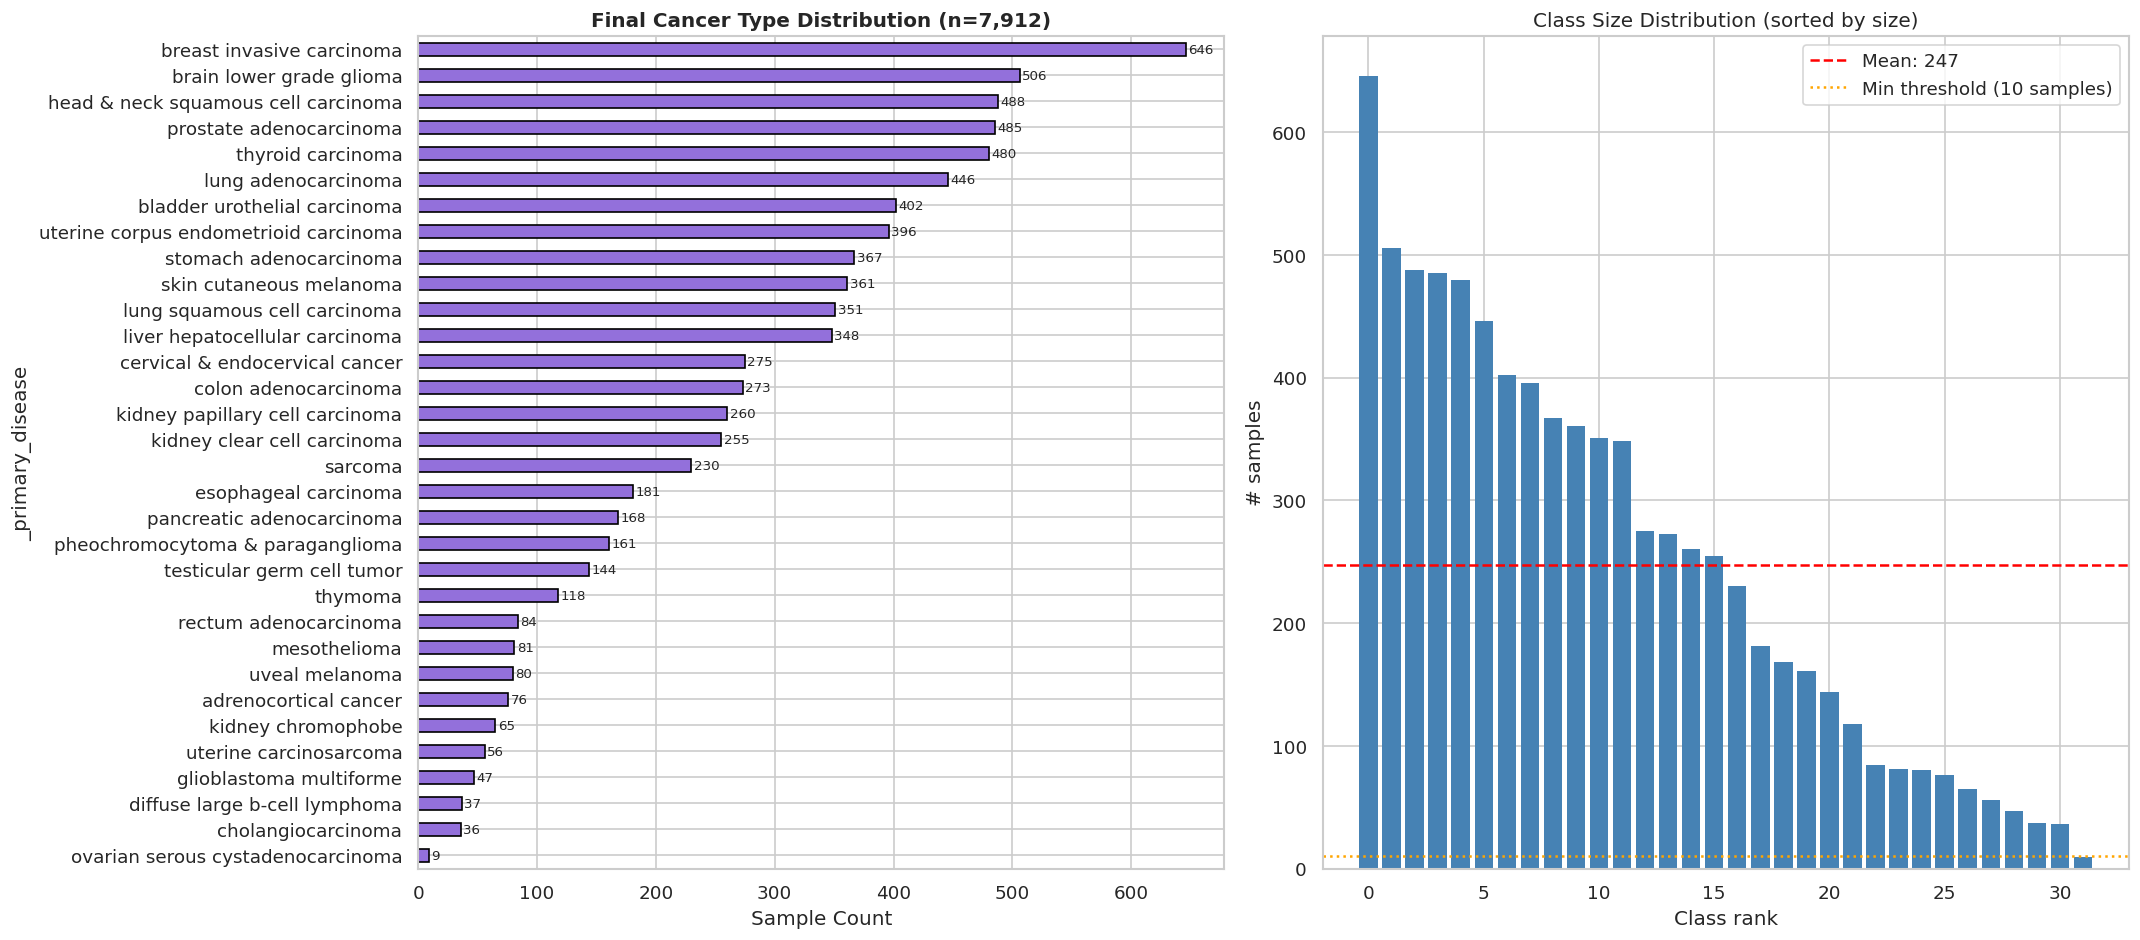


Class statistics:
  Largest class:   646 (breast invasive carcinoma)
  Smallest class:  9 (ovarian serous cystadenocarcinoma)
  Imbalance ratio: 71.8×

Samples remaining after min-class filter (10): 7,903 / 7,912


In [8]:
section('8. FINAL FILTERING & COMBINED EDA')

# ── 1. mRNA Imputation ──
nan_before = mrna.isnull().sum().sum()
if nan_before > 0:
    print(f'Imputing {nan_before:,} remaining mRNA NaN values with gene-wise mean...')
    mrna = mrna.fillna(mrna.mean(axis=0))

# ── 2. Variance Thresholding ──
print(f'Removing bottom {MRNA_VAR_QUANTILE*100:.0f}% lowest-variance genes...')
gene_var   = mrna.var(axis=0)
keep_genes = gene_var[gene_var > gene_var.quantile(MRNA_VAR_QUANTILE)].index

mrna = mrna[keep_genes].astype(np.float32)
cnv  = cnv[keep_genes]
mut  = mut[keep_genes]
if METH_LOADED:
    # Only keep genes that survived variance filter AND exist in meth
    meth_keep = [g for g in keep_genes if g in meth.columns]
    meth = meth[meth_keep].astype(np.float32)
    # Re-sync: restrict all to the final common set
    final_genes = sorted(set(mrna.columns) & set(cnv.columns) &
                         set(mut.columns) & set(meth.columns))
    mrna = mrna[final_genes]
    cnv  = cnv[final_genes]
    mut  = mut[final_genes]
    meth = meth[final_genes]
    print(f'Genes after variance filter + meth intersect: {len(final_genes):,}')

print('\n─── FINAL DATASET SHAPES & MEMORY ───')
mem_usage(mrna, 'mRNA final')
mem_usage(cnv,  'CNV final')
mem_usage(mut,  'Mutation final')
if METH_LOADED:
    mem_usage(meth, 'Methylation final')

# ── 3. Final Class Distribution EDA ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
class_counts = labels['_primary_disease'].value_counts()

class_counts.plot(kind='barh', ax=axes[0], color='mediumpurple', edgecolor='black')
axes[0].set_title(
    f'Final Cancer Type Distribution (n={len(common_patients):,})',
    fontweight='bold')
axes[0].set_xlabel('Sample Count')
axes[0].invert_yaxis()
for i, val in enumerate(class_counts.values):
    axes[0].text(val + 2, i, str(val), va='center', fontsize=8)

axes[1].bar(range(len(class_counts)), class_counts.values,
            color='steelblue', edgecolor='none')
axes[1].axhline(class_counts.mean(), color='red', linestyle='--',
                label=f'Mean: {class_counts.mean():.0f}')
axes[1].axhline(MIN_CLASS_SAMPLES, color='orange', linestyle=':',
                label=f'Min threshold ({MIN_CLASS_SAMPLES} samples)')
axes[1].set_title('Class Size Distribution (sorted by size)')
axes[1].set_xlabel('Class rank'); axes[1].set_ylabel('# samples')
axes[1].legend()

plt.tight_layout(); plt.show()

print(f'\nClass statistics:')
print(f'  Largest class:   {class_counts.max():,} ({class_counts.idxmax()})')
print(f'  Smallest class:  {class_counts.min():,} ({class_counts.idxmin()})')
print(f'  Imbalance ratio: {class_counts.max() / class_counts.min():.1f}×')

# ── 4. Optional: drop cancer types with < MIN_CLASS_SAMPLES ──
valid_classes = class_counts[class_counts >= MIN_CLASS_SAMPLES].index
mask = labels['_primary_disease'].isin(valid_classes)
print(f'\nSamples remaining after min-class filter ({MIN_CLASS_SAMPLES}): '
      f'{mask.sum():,} / {len(mask):,}')


## Cell 9 — Save Output Files

In [9]:
section('9. SAVING OUTPUT FILES')

# Ensure all column names are plain Python strings (required for parquet)
mrna.columns = mrna.columns.astype(str)
cnv.columns  = cnv.columns.astype(str)
mut.columns  = mut.columns.astype(str)
labels.columns = labels.columns.astype(str)

print('Saving parquet files (fast, compressed, type-preserving)...')
mrna.to_parquet('mrna_final.parquet');     print('  mrna_final.parquet     ✅')
cnv.to_parquet('cnv_final.parquet');       print('  cnv_final.parquet      ✅')
mut.to_parquet('mut_final.parquet');       print('  mut_final.parquet      ✅')
labels.to_parquet('labels_final.parquet'); print('  labels_final.parquet   ✅')

if METH_LOADED:
    meth.columns = meth.columns.astype(str)
    meth.to_parquet('meth_final.parquet')
    print('  meth_final.parquet     ✅')

print('\n─── Summary ───')
print(f'  mrna_final.parquet    — {mrna.shape[0]:,} patients × {mrna.shape[1]:,} genes | float32')
print(f'  cnv_final.parquet     — {cnv.shape[0]:,} patients × {cnv.shape[1]:,} genes | int8')
print(f'  mut_final.parquet     — {mut.shape[0]:,} patients × {mut.shape[1]:,} genes | int8')
if METH_LOADED:
    print(f'  meth_final.parquet    — {meth.shape[0]:,} patients × {meth.shape[1]:,} genes | float32')
print(f'  labels_final.parquet  — {labels.shape[0]:,} patients × 1 label column')

print('''
─── How to load in your DL notebook ───
  import pandas as pd
  mrna   = pd.read_parquet("mrna_final.parquet")
  cnv    = pd.read_parquet("cnv_final.parquet")
  mut    = pd.read_parquet("mut_final.parquet")
  meth   = pd.read_parquet("meth_final.parquet")   # if METH_LOADED
  labels = pd.read_parquet("labels_final.parquet")
  # All matrices are patient-aligned — same row order guaranteed.
''')

print('\nAll processing complete! 🚀')



═════════════════════════════════════════════════════════════════
  9. SAVING OUTPUT FILES
═════════════════════════════════════════════════════════════════
Saving parquet files (fast, compressed, type-preserving)...
  mrna_final.parquet     ✅
  cnv_final.parquet      ✅
  mut_final.parquet      ✅
  labels_final.parquet   ✅
  meth_final.parquet     ✅

─── Summary ───
  mrna_final.parquet    — 7,912 patients × 15,816 genes | float32
  cnv_final.parquet     — 7,912 patients × 15,816 genes | int8
  mut_final.parquet     — 7,912 patients × 15,816 genes | int8
  meth_final.parquet    — 7,912 patients × 15,816 genes | float32
  labels_final.parquet  — 7,912 patients × 1 label column

─── How to load in your DL notebook ───
  import pandas as pd
  mrna   = pd.read_parquet("mrna_final.parquet")
  cnv    = pd.read_parquet("cnv_final.parquet")
  mut    = pd.read_parquet("mut_final.parquet")
  meth   = pd.read_parquet("meth_final.parquet")   # if METH_LOADED
  labels = pd.read_parquet("labels_fin